In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from matplotlib_venn import venn3
from upsetplot import from_indicators, UpSet

code_list= "../data/matrix_codelists_combined-2025-08-07.csv"
HF_pheno_definitions = "../data/Initial HF phenotype definitions.xlsx"

code_list= pd.read_csv(code_list)
HF_pheno_definitions = pd.read_excel(HF_pheno_definitions, sheet_name="Table 1")

In [2]:
code_list.head()

,Code,Description,pheno_20,pheno_21,pheno_24,pheno_25,pheno_27,pheno_28,pheno_29,pheno_30,...,pheno_11,pheno_12,pheno_01,pheno_02,pheno_13,pheno_16,pheno_33,pheno_37,Person.count.in.SDE,In.Refset
0,10091002,High output heart failure (disorder),1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0.0,No
1,1010444007,Legal abortion complicated by cardiac failure ...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,No
2,1010447000,Illegal abortion complicated by cardiac failur...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,No
3,101281000119107,Congestive heart failure due to cardiomyopathy...,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0.0,No
4,10335000,Chronic right-sided heart failure (disorder),1,1,0,1,0,1,1,1,...,1,1,0,0,0,0,0,0,1275.0,No


#### "manually review the similarity of pheno_28, 29 and 30"

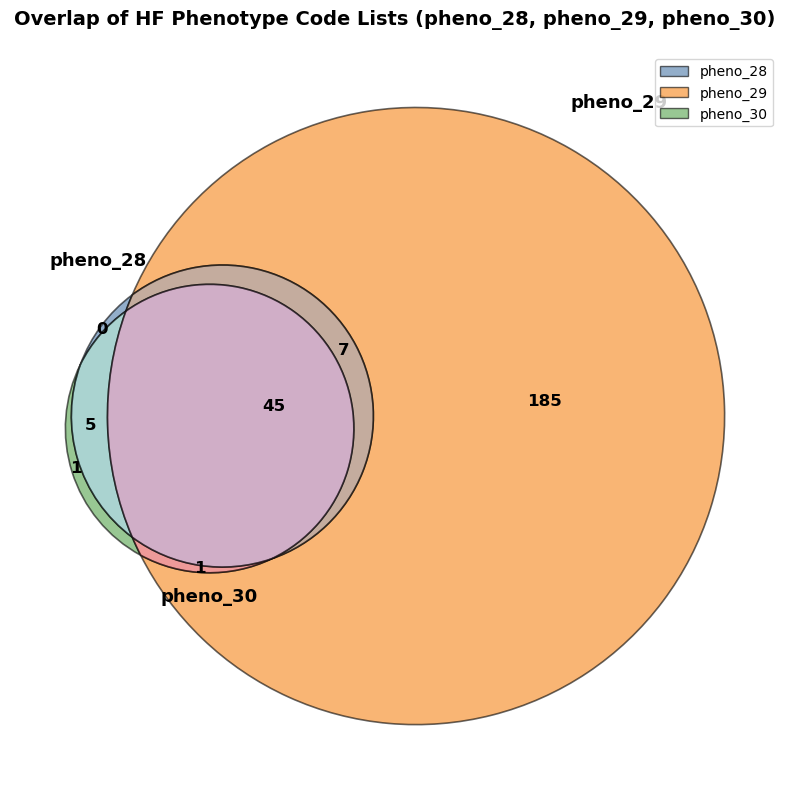

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

set28 = set(code_list.loc[code_list["pheno_28"] == 1, "Code"])
set29 = set(code_list.loc[code_list["pheno_29"] == 1, "Code"])
set30 = set(code_list.loc[code_list["pheno_30"] == 1, "Code"])

fig, ax = plt.subplots(figsize=(8, 8))

v = venn3(
    [set28, set29, set30],
    set_labels=("pheno_28", "pheno_29", "pheno_30"),
    ax=ax
)

# 自定义颜色
region_colors = {
    "100": "#4C78A8",  # 28 only
    "010": "#F58518",  # 29 only
    "001": "#54A24B",  # 30 only
    "110": "#9D755D",
    "101": "#72B7B2",
    "011": "#E45756",
    "111": "#B279A2"
}

# 设置区域颜色和透明度
for region_id, color in region_colors.items():
    patch = v.get_patch_by_id(region_id)
    if patch:
        patch.set_color(color)
        patch.set_alpha(0.6)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)

# 调整子集数字样式
for region_id in ["100", "010", "001", "110", "101", "011", "111"]:
    label = v.get_label_by_id(region_id)
    if label:
        label.set_fontsize(12)
        label.set_fontweight("bold")
        label.set_color("black")

# 调整集合标签样式
for label in v.set_labels:
    if label:
        label.set_fontsize(13)
        label.set_fontweight("bold")

ax.set_title("Overlap of HF Phenotype Code Lists (pheno_28, pheno_29, pheno_30)",
             fontsize=14, fontweight="bold", pad=20)

# 加 legend
legend_elements = [
    Patch(facecolor="#4C78A8", edgecolor="black", alpha=0.6, label="pheno_28"),
    Patch(facecolor="#F58518", edgecolor="black", alpha=0.6, label="pheno_29"),
    Patch(facecolor="#54A24B", edgecolor="black", alpha=0.6, label="pheno_30")
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
def plot_phenotype_venn(*pheno_nums, data=code_list, figsize=(10, 8)):
    """
    Plot a Venn diagram for phenotype code comparisons with similarity summary.
    
    Parameters:
    -----------
    *pheno_nums : int
        Phenotype numbers to compare (e.g., 28, 29, 30)
    data : pd.DataFrame
        The dataframe containing phenotype columns (default: code_list)
    figsize : tuple
        Figure size (default: (10, 8))
    
    Returns:
    --------
    dict : Summary statistics of the phenotypes
    """
    from matplotlib_venn import venn2, venn3
    from itertools import combinations
    
    # Validate input
    if len(pheno_nums) < 2 or len(pheno_nums) > 3:
        raise ValueError("Please provide 2 or 3 phenotype numbers")
    
    # Get sets for each phenotype
    pheno_sets = {}
    for num in pheno_nums:
        col_name = f"pheno_{num}"
        if col_name not in data.columns:
            raise ValueError(f"Column '{col_name}' not found in data")
        pheno_sets[num] = set(data.loc[data[col_name] == 1, "Code"])
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define colors
    colors = ["#4C78A8", "#F58518", "#54A24B", "#9D755D", "#72B7B2", "#E45756", "#B279A2"]
    
    # Plot venn diagram
    if len(pheno_nums) == 2:
        num1, num2 = pheno_nums
        v = venn2([pheno_sets[num1], pheno_sets[num2]], 
                  set_labels=(f"pheno_{num1}", f"pheno_{num2}"),
                  ax=ax,
                  set_colors=colors[:2])
    else:  # len == 3
        num1, num2, num3 = pheno_nums
        v = venn3([pheno_sets[num1], pheno_sets[num2], pheno_sets[num3]], 
                  set_labels=(f"pheno_{num1}", f"pheno_{num2}", f"pheno_{num3}"),
                  ax=ax,
                  set_colors=colors[:3])
    
    # Format labels
    for label in v.set_labels:
        if label:
            label.set_fontsize(12)
            label.set_fontweight("bold")
    
    for text in v.subset_labels:
        if text:
            text.set_fontsize(11)
            text.set_fontweight("bold")
    
    ax.set_title(f"Overlap of HF Phenotypes: {', '.join([f'pheno_{n}' for n in pheno_nums])}", 
                 fontsize=14, fontweight="bold", pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Generate summary statistics
    print("\n" + "="*60)
    print("SIMILARITY SUMMARY")
    print("="*60)
    
    # Total codes in each phenotype
    for num in pheno_nums:
        print(f"pheno_{num}: {len(pheno_sets[num])} codes")
    
    # Pairwise intersections (ranked by similarity)
    intersections = []
    for num_a, num_b in combinations(pheno_nums, 2):
        intersection = pheno_sets[num_a] & pheno_sets[num_b]
        size_a = len(pheno_sets[num_a])
        size_b = len(pheno_sets[num_b])
        
        # Jaccard similarity
        union = pheno_sets[num_a] | pheno_sets[num_b]
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0
        
        intersections.append({
            'pair': (num_a, num_b),
            'shared': len(intersection),
            'jaccard': jaccard,
            'size_a': size_a,
            'size_b': size_b
        })
    
    # Sort by Jaccard similarity (descending)
    intersections.sort(key=lambda x: x['jaccard'], reverse=True)
    
    print("\n📊 Ranking by Similarity (Jaccard Index):")
    print("-" * 60)
    for i, item in enumerate(intersections, 1):
        num_a, num_b = item['pair']
        print(f"{i}. pheno_{num_a} ↔ pheno_{num_b}")
        print(f"   Shared codes: {item['shared']} (Jaccard: {item['jaccard']:.2%})")
        print(f"   pheno_{num_a} unique: {item['size_a'] - item['shared']}")
        print(f"   pheno_{num_b} unique: {item['size_b'] - item['shared']}")
        print()
    
    # All three-way intersection (if applicable)
    if len(pheno_nums) == 3:
        all_three = pheno_sets[num1] & pheno_sets[num2] & pheno_sets[num3]
        print(f"🎯 All three phenotypes share: {len(all_three)} codes")
    
    print("="*60 + "\n")
    
    return intersections

# Example usage:
# plot_phenotype_venn(28, 29, 30)

In [12]:
set28

{'10335000',
 '10633002',
 '1110931000000103',
 '128404006',
 '134401001',
 '194767001',
 '194779001',
 '194781004',
 '195111005',
 '195112003',
 '195114002',
 '206586007',
 '233924009',
 '275514001',
 '314206003',
 '367363000',
 '407596008',
 '420300004',
 '420913000',
 '421704003',
 '422293003',
 '42343007',
 '426263006',
 '426611007',
 '430396006',
 '43736008',
 '446221000',
 '48447003',
 '56675007',
 '698592004',
 '703272007',
 '711461000000104',
 '716621000000101',
 '716971000000109',
 '717191000000108',
 '717491000000102',
 '717501000000108',
 '717531000000102',
 '71892000',
 '79955004',
 '83105008',
 '84114007',
 '85232009',
 '87837008',
 '88805009',
 '92506005',
 'I110',
 'I130',
 'I132',
 'I500',
 'I501',
 'I502',
 'I503',
 'I504',
 'I508',
 'I509',
 'I50_delete'}